# Phase 4: Graphs + baseline

**Skill:** turning a simulation into a learning problem, and being honest about baselines.

Phase 4 turns the ecosystem into a graph and trains a model to forecast it:

- **Graph builder:** 64 patch nodes (8×8 m each) plus one atmosphere node, with three edge types: `adjacent`, `downslope` and `hyphal`.
- **Dataset:** batched, headless research-mode runs. 28 two-year worlds under random interventions, snapshotted daily.
- **Supervised GNN:** heads for biomass, contamination, moisture, die-back and fungal links, at 24 h, 7 d and 30 d.
- **In-game overlay:** the trained model runs on the live world every sim-day.

**Done when:** the GNN beats persistence at 7 and 30 days, and forecasts are visible in-game.

This notebook uses the shipped model (`worldmodel/forecaster.npz`) through its numpy twin, so it doesn't need PyTorch. It generates its own held-out world (about 30 s).

In [1]:
import os, sys, json
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np

from sim.engine import Simulation
from worldmodel.dataset import generate_run
from worldmodel.forecast import NumpyForecaster
from worldmodel.graph import F, adjacent_pairs, edges, snapshot
from worldmodel.targets import HORIZONS_DAYS, build_samples, scores

%matplotlib inline

## 1. The ecosystem as a graph

Each patch node carries 14 features: plant C and C:N; litter, SOM and the three microbial guilds; insects; mineral N and P; contaminant; moisture; elevation; and the network's trade bias. The atmosphere node carries season and recent weather.

Edges are derived from node features rather than stored. Downslope edges come from elevation, and hyphal edges come from which patches are on the fungal network.

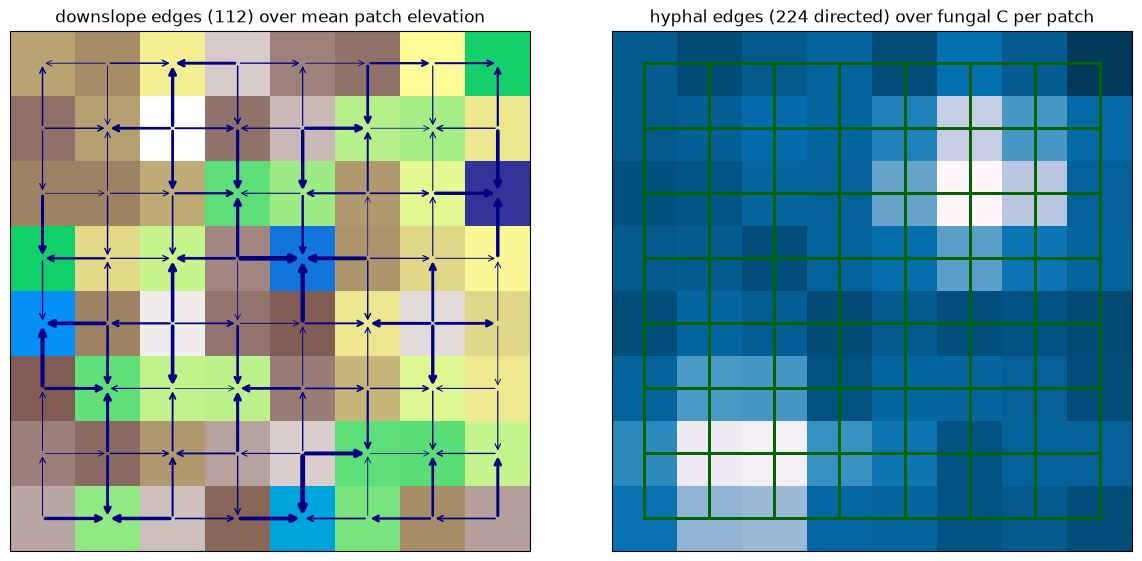

In [2]:
sim = Simulation(seed=7)
sim.run(24 * 150)
snap = snapshot(sim)
e = edges(snap.x, 8, 8)
cx, cy = np.meshgrid(np.arange(8) + 0.5, np.arange(8) + 0.5)
cx, cy = cx.ravel(), cy.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
ax = axes[0]
ax.imshow(snap.x[:, F["elevation"]].reshape(8, 8), cmap="terrain", extent=(0, 8, 8, 0))
(src, dst), w = e["downslope"]
for s, d, ww in zip(src, dst, w):
    ax.annotate("", (cx[d], cy[d]), (cx[s], cy[s]),
                arrowprops=dict(arrowstyle="->", color="navy", lw=0.5 + 3 * ww / w.max()))
ax.set_title(f"downslope edges ({len(w)}) over mean patch elevation")
ax = axes[1]
ax.imshow(snap.x[:, F["mycorrhiza_c"]].reshape(8, 8), cmap="PuBu", extent=(0, 8, 8, 0))
(src, dst), _ = e["hyphal"]
for s, d in zip(src, dst):
    ax.plot([cx[s], cx[d]], [cy[s], cy[d]], color="darkgreen", lw=2)
ax.set_title(f"hyphal edges ({len(src)} directed) over fungal C per patch")
for a in axes:
    a.set_xticks([]); a.set_yticks([])

## 2. Targets and the baseline to beat

A forecast is only interesting if it beats something cheap. The baseline here is **persistence**:

- for biomass, contamination and moisture, "nothing will change";
- for die-back, "the last window's rate will repeat";
- for fungal links, "today's links stay".

Skill is `1 − model error / persistence error` (MAE, or Brier score for links). Zero means no better than persistence; 1 means perfect.

samples: {'train': 13400, 'val': 2680, 'test': 2680} | split by world seed: {'train': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], 'val': [20, 21, 22, 23], 'test': [24, 25, 26, 27]}


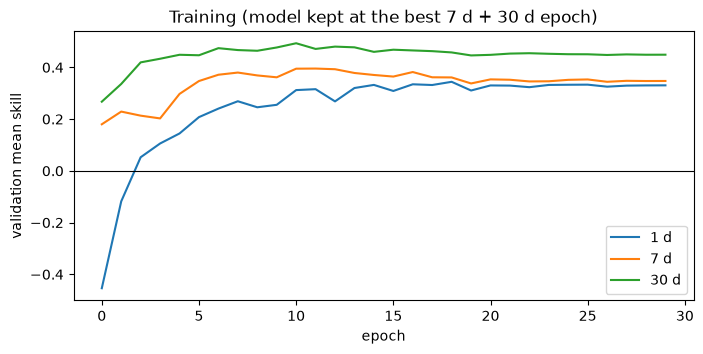

In [3]:
metrics = json.loads(Path("worldmodel/forecaster_metrics.json").read_text())
print("samples:", metrics["samples"], "| split by world seed:", metrics["splits"])
curve = metrics["curve"]
fig, ax = plt.subplots(figsize=(8, 3.5))
for h in HORIZONS_DAYS:
    ax.plot([c[f"val_skill@{h}d"] for c in curve], label=f"{h} d")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="epoch", ylabel="validation mean skill", title="Training (model kept at the best 7 d + 30 d epoch)")
ax.legend();

{'mean@1d': 0.257, 'mean@7d': 0.355, 'mean@30d': 0.433}


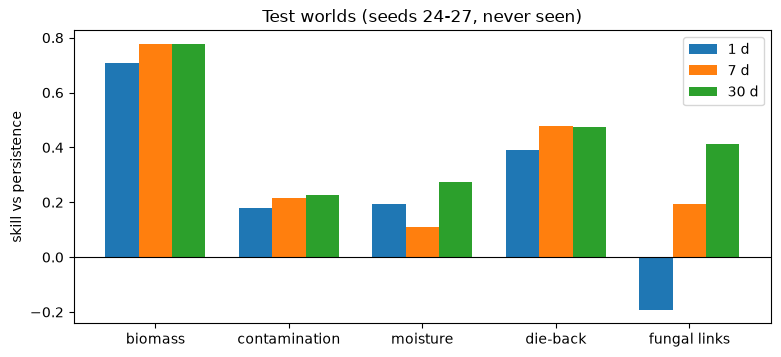

In [4]:
heads = ["biomass", "contamination", "moisture", "mortality", "links"]
test = metrics["test"]
fig, ax = plt.subplots(figsize=(9, 3.8))
width = 0.25
for k, h in enumerate(HORIZONS_DAYS):
    vals = [test[f"{n}@{h}d"]["skill"] for n in heads]
    ax.bar(np.arange(len(heads)) + (k - 1) * width, vals, width, label=f"{h} d")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(heads)), ["biomass", "contamination", "moisture", "die-back", "fungal links"])
ax.set(ylabel="skill vs persistence", title="Test worlds (seeds 24-27, never seen)")
ax.legend()
print({f"mean@{h}d": round(test[f"mean_skill@{h}d"], 3) for h in HORIZONS_DAYS})

Biomass is the clear win. Persistence can't know that spring is coming; the model can, from the season features and each patch's recent trend. Die-back also beats its "same as last month" baseline by a wide margin.

The one red bar is **fungal links at 24 h**. The network almost never changes overnight, so "today's links" is nearly perfect, and any uncertainty the model expresses costs it Brier score. At 30 days links do change, and the model wins clearly.

## 3. A world nobody trained on

The CI gate does exactly this: generate a fresh world (seed 1000, one meadow-year) and score the shipped model on it.

In [5]:
model = NumpyForecaster()
run = generate_run(1000, days=365)
s = build_samples(run)
m = model.meta
pred = model.decode(*model.raw((s["nodes"] - m["node_mean"]) / m["node_std"],
                               (s["glob"] - m["glob_mean"]) / m["glob_std"],
                               s["on"], s["elev"], s["link_now"].astype(float)))
held = scores(pred, s)
for h in HORIZONS_DAYS:
    row = "  ".join(f"{n[:7]} {held[f'{n}@{h}d']['skill']:+.2f}" for n in heads)
    print(f"{h:>2} d  mean {held[f'mean_skill@{h}d']:+.3f} | {row}")

 1 d  mean +0.268 | biomass +0.62  contami +0.04  moistur +0.23  mortali +0.45  links +0.00
 7 d  mean +0.243 | biomass +0.65  contami +0.06  moistur +0.02  mortali +0.48  links +0.00
30 d  mean +0.282 | biomass +0.62  contami +0.06  moistur +0.31  mortali +0.44  links -0.01


The margins are thinner on this single quiet meadow than on the four mixed test worlds. Biomass and die-back still carry the model. Contamination barely moves in an undisturbed meadow, so there's little to predict, and links never change, so persistence is already perfect. The gate checks the mean over heads, and it passes at 7 and 30 days, but the per-head numbers are the more honest picture.

forecast made on day 101; MAE model 0.028, persistence 0.324


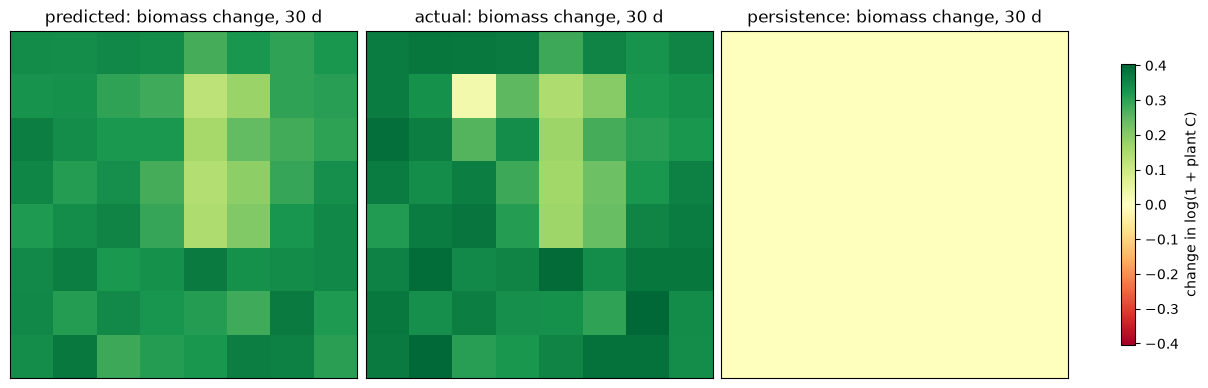

In [6]:
day_idx = int(np.argmin(np.abs(s["day"] - 100)))  # early April: growth season starting
h = 30; k = HORIZONS_DAYS.index(h)
maps = {"predicted": pred["biomass"][day_idx, :, k], "actual": s["y_biomass"][day_idx, :, k],
        "persistence": np.zeros(64)}
lim = np.abs(maps["actual"]).max()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, (name, v) in zip(axes, maps.items()):
    im = ax.imshow(v.reshape(8, 8), cmap="RdYlGn", vmin=-lim, vmax=lim)
    ax.set_title(f"{name}: biomass change, {h} d"); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.8, label="change in log(1 + plant C)")
print(f"forecast made on day {s['day'][day_idx] + 1}; MAE model {np.abs(maps['predicted'] - maps['actual']).mean():.3f}, "
      f"persistence {np.abs(maps['actual']).mean():.3f}")

## 4. Speed

The roadmap targets at least 1,000 ticks/s for dataset generation.

- **Per process:** compiling the lateral-transport kernel with Numba raised a single sim from 246 to about 325 ticks/s. The kernel is bit-identical to the numpy version, so replay hashes didn't change.
- **Batched:** with 2 worker processes, the full dataset (490,560 ticks) ran at **557 ticks/s**.

That **misses the target on this 2-core sandbox**. Runs are independent, so throughput scales with cores: about 4 cores would reach it. Beating it per process would mean compiling whole modules (hydrology, decomposers, mycorrhiza). After `route`, the time is spread across hundreds of small array operations, not concentrated in one hotspot.

## What broke

- **PyTorch's CPU wheel index is blocked here,** and PyPI's PyTorch is the 3 GB CUDA build. The response became a design choice: train in PyTorch, export the weights, and run inference in a numpy twin. A test checks the two agree to about 1e-7, so the game server and CI never need PyTorch.
- **The first Numba kernel was only 2.3× faster.** Shared fractions were being broadcast and copied on every call. Indexing the shared array directly fixed it.
- **Checking mass balance daily instead of hourly gave no measurable speedup,** so I reverted it. The check was never the bottleneck.
- **The overlay was first invisible, then wrong.** A fixed color scale made winter forecasts too faint to see. A visibility floor then painted noise (±0.002) on clean meadow patches red. The fix: scale tints by each head's typical change at that horizon, and leave a dead zone.
- **PyTorch Geometric was planned but turned out unnecessary.** With 64 nodes, dense per-type adjacency in plain PyTorch is faster to write and easier to read.

## Known issues

- **Links at 24 h lose to persistence.** It's cosmetic for gameplay, but a cleaner model would learn to defer to persistence at short horizons.
- **No interventions as inputs.** The model doesn't know what the player just did; it only sees the world afterwards. Phase 5's action-conditioned latent dynamics is where that belongs.
- **The training data has no agents.** Research-mode runs leave out the mycelial keystone agent, so its actions in-game are slightly out of distribution.
- **No forecast-vs-actual check in-game yet.** Showing it would make the overlay's accuracy visible during play.

## Try it

1. Retrain with `--hidden 32`. How much skill do you lose at half the parameters?
2. Drop the 7-day trend features in `targets.node_inputs`. Which head suffers most, and why?
3. In the game, put compost on a bare patch and watch the 30-day biomass forecast. The model doesn't see the action itself, so when does the forecast catch up?